# Atari 100k BBF (Bigger, Better, Faster) Algorithm

This notebook demonstrates the BBF (Bigger, Better, Faster) algorithm on the Atari 100k benchmark. BBF is a sample-efficient deep reinforcement learning algorithm that combines:

1. **Bigger Networks**: Larger neural network architectures for better representation learning
2. **Better Training**: Advanced training techniques including self-supervised learning and data augmentation
3. **Faster Updates**: Efficient experience replay and optimization strategies

The Atari 100k benchmark constrains agents to learn from only 100,000 environment steps (approximately 2 hours of human play), making sample efficiency critical.

---

**Reference**: "Bigger, Better, Faster: Human-level Atari with human-level efficiency" (Schwarzer et al., 2021)

## 1. Install and Import Required Libraries

We'll install the necessary packages for the BBF algorithm and Atari environments, including specialized packages for image augmentation and self-supervised learning.

In [14]:
# Install required packages
%pip install gymnasium[atari] ale-py torch torchvision numpy matplotlib wandb tsilva-notebook-utils kornia --quiet

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 759c03bb1110, raw_cell="# Install required packages
%pip install gymnasium.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X30sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Note: you may need to restart the kernel to use updated packages.
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 759c03aeab10, execution_count=14 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 759c03bb1110, raw_cell="# Install required packages
%pip install gymnasium.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X30sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [15]:
import gymnasium as gym
import ale_py

# Make arcade learning environment available in gymnasium
gym.register_envs(ale_py)

# Retrieve list of available Pong environments
keys = gym.envs.registration.registry.keys()
[key for key in keys if "Pong" in key]

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 75992a85ac10, raw_cell="import gymnasium as gym
import ale_py

# Make arca.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

['Pong-v0',
 'Pong-v4',
 'PongNoFrameskip-v0',
 'PongNoFrameskip-v4',
 'ALE/Pong-v5']

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7599296e6690, execution_count=15 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 75992a85ac10, raw_cell="import gymnasium as gym
import ale_py

# Make arca.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D> result=['Pong-v0', 'Pong-v4', 'PongNoFrameskip-v0', 'PongNoFrameskip-v4', 'ALE/Pong-v5']>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [16]:
# Load secrets and login to wandb
from tsilva_notebook_utils.colab import load_secrets_into_env

_ = load_secrets_into_env([
    'WANDB_API_KEY',
    'NOTIFICATION_URL', 
    'NOTIFICATION_AUTH_TOKEN'
])

import wandb
wandb.login()

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7599295c8a50, raw_cell="# Load secrets and login to wandb
from tsilva_note.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X32sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7599295c8350, execution_count=16 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7599295c8a50, raw_cell="# Load secrets and login to wandb
from tsilva_note.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X32sdnNjb2RlLXJlbW90ZQ%3D%3D> result=True>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [17]:
# Import all required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import os
from collections import deque
from typing import Tuple, Dict, Any, Optional

# Image processing and augmentation
import kornia.augmentation as K
from torchvision import transforms

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"All imports successful! PyTorch version: {torch.__version__}")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 75992960a410, raw_cell="# Import all required libraries
import torch
impor.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X33sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Using device: cuda
All imports successful! PyTorch version: 2.5.1
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7599296086d0, execution_count=17 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 75992960a410, raw_cell="# Import all required libraries
import torch
impor.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X33sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

## 2. Set Up Atari Environment (100k Benchmark)

We'll set up an Atari environment with standard preprocessing wrappers for the 100k benchmark. This includes frame stacking, gray-scaling, and resizing to 84x84 pixels.

In [26]:
# Atari environment wrappers for preprocessing
import cv2

class NoopResetEnv(gym.Wrapper):
    """Sample initial states by taking random number of no-ops on reset."""
    def __init__(self, env, noop_max=30):
        gym.Wrapper.__init__(self, env)
        self.noop_max = noop_max
        self.override_num_noops = None
        self.noop_action = 0
        assert env.unwrapped.get_action_meanings()[0] == 'NOOP'

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        if self.override_num_noops is not None:
            noops = self.override_num_noops
        else:
            noops = self.unwrapped.np_random.integers(1, self.noop_max + 1)
        assert noops > 0
        for _ in range(noops):
            obs, _, terminated, truncated, _ = self.env.step(self.noop_action)
            if terminated or truncated:
                obs, info = self.env.reset(**kwargs)
        return obs, info

class MaxAndSkipEnv(gym.Wrapper):
    """Return only every `skip`-th frame"""
    def __init__(self, env, skip=4):
        gym.Wrapper.__init__(self, env)
        self._obs_buffer = np.zeros((2,) + env.observation_space.shape, dtype=np.uint8)
        self._skip = skip

    def step(self, action):
        total_reward = 0.0
        terminated = truncated = None
        for i in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            if i == self._skip - 2: self._obs_buffer[0] = obs
            if i == self._skip - 1: self._obs_buffer[1] = obs
            total_reward += reward
            if terminated or truncated:
                break
        max_frame = self._obs_buffer.max(axis=0)
        return max_frame, total_reward, terminated, truncated, info

class EpisodicLifeEnv(gym.Wrapper):
    """Make end-of-life == end-of-episode, but only reset on true game over."""
    def __init__(self, env):
        gym.Wrapper.__init__(self, env)
        self.lives = 0
        self.was_real_done = True

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.was_real_done = terminated or truncated
        lives = self.env.unwrapped.ale.lives()
        if lives < self.lives and lives > 0:
            terminated = True
        self.lives = lives
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        if self.was_real_done:
            obs, info = self.env.reset(**kwargs)
        else:
            obs, reward, terminated, truncated, info = self.env.step(0)
        self.lives = self.env.unwrapped.ale.lives()
        return obs, info

class FireResetEnv(gym.Wrapper):
    """Take action on reset for environments that are fixed until firing."""
    def __init__(self, env):
        gym.Wrapper.__init__(self, env)
        assert env.unwrapped.get_action_meanings()[1] == 'FIRE'
        assert len(env.unwrapped.get_action_meanings()) >= 3

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        obs, _, terminated, truncated, _ = self.env.step(1)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)
        obs, _, terminated, truncated, _ = self.env.step(2)
        if terminated or truncated:
            obs, info = self.env.reset(**kwargs)
        return obs, info

class WarpFrame(gym.ObservationWrapper):
    """Warp frames to 84x84 as done in the Nature paper and later work."""
    def __init__(self, env, width=84, height=84, grayscale=True, dict_space_key=None):
        super().__init__(env)
        self._width = width
        self._height = height
        self._grayscale = grayscale
        self._key = dict_space_key
        if self._grayscale:
            num_colors = 1
        else:
            num_colors = 3

        new_space = gym.spaces.Box(
            low=0,
            high=255,
            shape=(self._height, self._width, num_colors),
            dtype=np.uint8,
        )
        if self._key is None:
            original_space = self.observation_space
            self.observation_space = new_space
        else:
            original_space = self.observation_space.spaces[self._key]
            self.observation_space.spaces[self._key] = new_space
        assert original_space.dtype == np.uint8 and len(original_space.shape) == 3

    def observation(self, obs):
        if self._key is None:
            obs_space = obs
        else:
            obs_space = obs[self._key]

        if self._grayscale:
            obs_space = cv2.cvtColor(obs_space, cv2.COLOR_RGB2GRAY)
        obs_space = cv2.resize(obs_space, (self._width, self._height), interpolation=cv2.INTER_AREA)
        if self._grayscale:
            obs_space = np.expand_dims(obs_space, -1)

        if self._key is None:
            return obs_space
        else:
            obs[self._key] = obs_space
            return obs

class ScaledFloatFrame(gym.ObservationWrapper):
    """Normalize pixel values to [0, 1]."""
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=env.observation_space.shape, dtype=np.float32)

    def observation(self, observation):
        return np.array(observation).astype(np.float32) / 255.0

class ClipRewardEnv(gym.RewardWrapper):
    """Clip rewards to {-1, 0, 1}."""
    def __init__(self, env):
        gym.RewardWrapper.__init__(self, env)

    def reward(self, reward):
        return np.sign(reward)

class FrameStack(gym.Wrapper):
    """Stack k last frames."""
    def __init__(self, env, k):
        gym.Wrapper.__init__(self, env)
        self.k = k
        self.frames = deque([], maxlen=k)
        shp = env.observation_space.shape
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(shp[:-1] + (shp[-1] * k,)), dtype=env.observation_space.dtype)

    def reset(self, **kwargs):
        ob, info = self.env.reset(**kwargs)
        for _ in range(self.k):
            self.frames.append(ob)
        return self._get_ob(), info

    def step(self, action):
        ob, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(ob)
        return self._get_ob(), reward, terminated, truncated, info

    def _get_ob(self):
        assert len(self.frames) == self.k
        return np.concatenate(list(self.frames), axis=-1)

def make_atari_env(env_id='PongNoFrameskip-v4', seed=None):
    """Create an Atari environment with standard wrappers."""
    env = gym.make(env_id)
    if seed is not None:
        env.reset(seed=seed)
        if hasattr(env.action_space, 'seed'):
            env.action_space.seed(seed)
        if hasattr(env.observation_space, 'seed'):
            env.observation_space.seed(seed)
    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)
    env = EpisodicLifeEnv(env)
    if 'FIRE' in env.unwrapped.get_action_meanings():
        env = FireResetEnv(env)
    env = WarpFrame(env)
    env = ScaledFloatFrame(env)
    env = ClipRewardEnv(env)
    env = FrameStack(env, 4)
    return env

# Configuration for BBF algorithm - DIAGNOSTIC VERSION 
CONFIG = {
    'env_id': 'PongNoFrameskip-v4',
    'max_env_steps': 10000,  # Even shorter for fast diagnostic
    'seed': SEED,
    'lr': 1e-4,
    'gamma': 0.99,
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'epsilon_frames': 3000,  # Much faster epsilon decay (30% of total)
    'replay_buffer_size': 100000,
    'batch_size': 32,
    'update_frequency': 4,
    'target_update_frequency': 1000,  # More frequent updates
    'eval_frequency': 2500,  # More frequent evaluation
    'num_eval_episodes': 5,  # Faster evaluation
    'learning_starts': 500,  # Start learning earlier
    
    # BBF specific parameters
    'aug_prob': 0.1,
    'ssl_coef': 0.02,  # Further reduced to let Q-loss dominate
    'bisim_coef': 0.02,
    'hidden_dim': 512,
}

print(f"Configuration: {CONFIG}")

# Create environment
env = make_atari_env(CONFIG['env_id'], CONFIG['seed'])
print(f"Environment: {CONFIG['env_id']}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Number of actions: {env.action_space.n}")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 759af1de8e50, raw_cell="# Atari environment wrappers for preprocessing
imp.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X35sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Configuration: {'env_id': 'PongNoFrameskip-v4', 'max_env_steps': 10000, 'seed': 42, 'lr': 0.0001, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_end': 0.01, 'epsilon_frames': 3000, 'replay_buffer_size': 100000, 'batch_size': 32, 'update_frequency': 4, 'target_update_frequency': 1000, 'eval_frequency': 2500, 'num_eval_episodes': 5, 'learning_starts': 500, 'aug_prob': 0.1, 'ssl_coef': 0.02, 'bisim_coef': 0.02, 'hidden_dim': 512}
Environment: PongNoFrameskip-v4
Observation space: Box(0.0, 1.0, (84, 84, 4), float32)
Action space: Discrete(6)
Number of actions: 6
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 759af830a7d0, execution_count=26 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 759af1de8e50, raw_cell="# Atari environment wrappers for preprocessing
imp.." store_history=True silent=False shell_futures=True cell_id

BrokenPipeError: [Errno 32] Broken pipe

## 3. Define BBF Algorithm Components

The BBF algorithm incorporates several advanced techniques:
- **Data Augmentation**: Random crops and color jittering
- **Self-Supervised Learning**: Contrastive learning for better representations
- **Bisimulation Metrics**: Learning state representations that preserve reward structure

In [19]:
# Data augmentation transforms for BBF
class DataAugmentation(nn.Module):
    """Data augmentation module using Kornia."""
    def __init__(self, img_size=84):
        super().__init__()
        self.aug = nn.Sequential(
            K.RandomCrop((img_size, img_size), padding=4, same_on_batch=False),
            K.RandomGrayscale(p=0.1, same_on_batch=False),
            K.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1, p=0.1, same_on_batch=False),
        )
    
    def forward(self, x):
        return self.aug(x)

# Self-supervised learning components
class ContrastiveLoss(nn.Module):
    """Contrastive loss for self-supervised representation learning."""
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        
    def forward(self, z1, z2):
        """
        z1, z2: [batch_size, feature_dim] - positive pairs
        """
        batch_size = z1.shape[0]
        
        # Normalize features
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        
        # Concatenate z1 and z2
        z = torch.cat([z1, z2], dim=0)  # [2*batch_size, feature_dim]
        
        # Compute similarity matrix
        sim_matrix = torch.mm(z, z.t()) / self.temperature  # [2*batch_size, 2*batch_size]
        
        # Create labels for positive pairs
        labels = torch.arange(batch_size).to(z.device)
        labels = torch.cat([labels + batch_size, labels], dim=0)
        
        # Remove self-similarities
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(z.device)
        sim_matrix = sim_matrix.masked_fill(mask, float('-inf'))
        
        # Compute cross-entropy loss
        loss = F.cross_entropy(sim_matrix, labels)
        return loss

class BisimLoss(nn.Module):
    """Bisimulation loss for learning reward-preserving representations."""
    def __init__(self):
        super().__init__()
        
    def forward(self, z1, z2, r1, r2, gamma=0.99):
        """
        z1, z2: state representations [batch_size, feature_dim]
        r1, r2: rewards [batch_size]
        """
        # Compute representation distance
        repr_dist = F.mse_loss(z1, z2, reduction='none').sum(dim=1)
        
        # Compute reward distance
        reward_dist = torch.abs(r1 - r2)
        
        # Bisimulation constraint: |z1 - z2| ≤ |r1 - r2| + γ * |z1_next - z2_next|
        # For simplicity, we use current state representations
        loss = F.relu(repr_dist - reward_dist).mean()
        return loss

def epsilon_greedy_action(q_values, epsilon):
    """Select action using epsilon-greedy policy."""
    if random.random() < epsilon:
        return random.randint(0, q_values.shape[-1] - 1)
    else:
        return q_values.argmax().item()

def linear_schedule(start_val, end_val, start_step, end_step, current_step):
    """Linear schedule for epsilon decay."""
    if current_step <= start_step:
        return start_val
    elif current_step >= end_step:
        return end_val
    else:
        return start_val + (end_val - start_val) * (current_step - start_step) / (end_step - start_step)

print("BBF algorithm components defined!")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7599295480d0, raw_cell="# Data augmentation transforms for BBF
class DataA.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X40sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

BBF algorithm components defined!
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 759929549350, execution_count=19 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7599295480d0, raw_cell="# Data augmentation transforms for BBF
class DataA.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X40sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

## 4. Implement Replay Buffer

The replay buffer stores transitions and provides efficient sampling for training. It supports data augmentation during sampling.

In [20]:
class ReplayBuffer:
    """Replay buffer for storing and sampling transitions."""
    
    def __init__(self, capacity, obs_shape, device):
        self.capacity = capacity
        self.device = device
        self.size = 0
        self.idx = 0
        
        # Pre-allocate memory
        self.observations = torch.zeros((capacity,) + obs_shape, dtype=torch.float32)
        self.actions = torch.zeros(capacity, dtype=torch.long)
        self.rewards = torch.zeros(capacity, dtype=torch.float32)
        self.next_observations = torch.zeros((capacity,) + obs_shape, dtype=torch.float32)
        self.dones = torch.zeros(capacity, dtype=torch.bool)
        
    def add(self, obs, action, reward, next_obs, done):
        """Add a transition to the buffer."""
        self.observations[self.idx] = torch.from_numpy(obs).float()
        self.actions[self.idx] = action
        self.rewards[self.idx] = reward
        self.next_observations[self.idx] = torch.from_numpy(next_obs).float()
        self.dones[self.idx] = done
        
        self.idx = (self.idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
    def sample(self, batch_size, aug_prob=0.0):
        """Sample a batch of transitions."""
        indices = torch.randint(0, self.size, (batch_size,))
        obs = self.observations[indices].to(self.device)
        actions = self.actions[indices].to(self.device)
        rewards = self.rewards[indices].to(self.device)
        next_obs = self.next_observations[indices].to(self.device)
        dones = self.dones[indices].to(self.device)
        # Apply data augmentation with probability aug_prob
        if aug_prob > 0.0 and random.random() < aug_prob:
            aug = DataAugmentation().to(self.device)
            # For grayscale, repeat last channel to 3 channels for Kornia
            # obs: (batch, 84, 84, 4) -> (batch, 4, 84, 84)
            obs_ = obs.permute(0, 3, 1, 2)
            next_obs_ = next_obs.permute(0, 3, 1, 2)
            # Use only the last frame for augmentation, repeat to 3 channels
            obs_last = obs_[:, -1:, :, :].repeat(1, 3, 1, 1)
            next_obs_last = next_obs_[:, -1:, :, :].repeat(1, 3, 1, 1)
            obs_aug = aug(obs_last)
            next_obs_aug = aug(next_obs_last)
            # Take only the first channel after augmentation, shape: (batch, 1, 84, 84)
            obs = obs_aug[:, :1, :, :].permute(0, 2, 3, 1).repeat(1, 1, 1, obs_.shape[1])
            next_obs = next_obs_aug[:, :1, :, :].permute(0, 2, 3, 1).repeat(1, 1, 1, next_obs_.shape[1])
        return obs, actions, rewards, next_obs, dones
    
    def sample_contrastive(self, batch_size):
        """Sample pairs for contrastive learning."""
        indices = torch.randint(0, self.size, (batch_size,))
        obs = self.observations[indices].to(self.device)
        aug = DataAugmentation().to(self.device)
        obs_ = obs.permute(0, 3, 1, 2)  # (batch, 4, 84, 84)
        obs_last = obs_[:, -1, :, :].unsqueeze(1)  # (batch, 1, 84, 84)
        obs_last_rgb = obs_last.repeat(1, 3, 1, 1)  # (batch, 3, 84, 84)
        obs_aug1 = aug(obs_last_rgb)
        obs_aug2 = aug(obs_last_rgb)
        obs_aug1 = obs_aug1[:, :1, :, :].permute(0, 2, 3, 1)  # (batch, 84, 84, 1)
        obs_aug2 = obs_aug2[:, :1, :, :].permute(0, 2, 3, 1)
        return obs_aug1, obs_aug2
    
    def __len__(self):
        return self.size

# Initialize replay buffer
replay_buffer = ReplayBuffer(
    capacity=min(CONFIG['replay_buffer_size'], 25000),  # Reduce buffer size for 31GB RAM
    obs_shape=env.observation_space.shape,
    device=device
)

print(f"Replay buffer initialized with capacity: {replay_buffer.capacity}")
print(f"Observation shape: {env.observation_space.shape}")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7599292d0c90, raw_cell="class ReplayBuffer:
    """Replay buffer for stori.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X42sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Replay buffer initialized with capacity: 25000
Observation shape: (84, 84, 4)
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7599292d2610, execution_count=20 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7599292d0c90, raw_cell="class ReplayBuffer:
    """Replay buffer for stori.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X42sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

## 5. Define Neural Network Architectures

We'll implement larger neural networks (the "Bigger" part of BBF) with convolutional layers for processing Atari frames and additional projection heads for self-supervised learning.

In [21]:
class CNNEncoder(nn.Module):
    """CNN encoder for processing Atari frames."""
    
    def __init__(self, obs_shape, hidden_dim=512):
        super().__init__()
        self.obs_shape = obs_shape
        self.hidden_dim = hidden_dim
        
        # Convolutional layers
        self.conv = nn.Sequential(
            nn.Conv2d(obs_shape[2], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        
        # Calculate conv output size
        conv_out_size = self._get_conv_out_size(obs_shape)
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        
    def _get_conv_out_size(self, shape):
        """Calculate the output size of convolutional layers."""
        x = torch.zeros(1, *shape)
        x = x.permute(0, 3, 1, 2)  # Change to (batch, channels, height, width)
        x = self.conv(x)
        return int(np.prod(x.size()))
    
    def forward(self, x):
        # Change from (batch, height, width, channels) to (batch, channels, height, width)
        x = x.permute(0, 3, 1, 2)
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

class BBFNetwork(nn.Module):
    """BBF network with Q-learning head and projection heads for self-supervised learning."""
    
    def __init__(self, obs_shape, num_actions, hidden_dim=512):
        super().__init__()
        self.num_actions = num_actions
        
        # Shared encoder
        self.encoder = CNNEncoder(obs_shape, hidden_dim)
        
        # Q-value head
        self.q_head = nn.Linear(hidden_dim, num_actions)
        
        # Projection head for contrastive learning
        self.projection_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 128)  # Smaller projection dimension
        )
        
        # Prediction head for bisimulation
        self.prediction_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x, return_features=False):
        features = self.encoder(x)
        q_values = self.q_head(features)
        
        if return_features:
            return q_values, features
        return q_values
    
    def get_features(self, x):
        """Get encoded features."""
        return self.encoder(x)
    
    def get_projection(self, x):
        """Get projection for contrastive learning."""
        features = self.encoder(x)
        return self.projection_head(features)
    
    def get_prediction(self, x):
        """Get prediction for bisimulation."""
        features = self.encoder(x)
        return self.prediction_head(features)

# Initialize networks
obs_shape = env.observation_space.shape
num_actions = env.action_space.n

q_network = BBFNetwork(obs_shape, num_actions, CONFIG['hidden_dim']).to(device)
target_network = BBFNetwork(obs_shape, num_actions, CONFIG['hidden_dim']).to(device)

# Copy weights to target network
target_network.load_state_dict(q_network.state_dict())

# Initialize optimizer
optimizer = optim.Adam(q_network.parameters(), lr=CONFIG['lr'])

# Initialize loss functions
criterion = nn.MSELoss()
contrastive_loss = ContrastiveLoss().to(device)
bisim_loss = BisimLoss().to(device)

print(f"Networks initialized!")
print(f"Q-network parameters: {sum(p.numel() for p in q_network.parameters()):,}")
print(f"Observation shape: {obs_shape}")
print(f"Number of actions: {num_actions}")

# Test forward pass
with torch.no_grad():
    test_obs = torch.randn(1, *obs_shape).to(device)
    test_q = q_network(test_obs)
    print(f"Test Q-values shape: {test_q.shape}")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 759929716e10, raw_cell="class CNNEncoder(nn.Module):
    """CNN encoder fo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X44sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Networks initialized!
Q-network parameters: 2,803,494
Observation shape: (84, 84, 4)
Number of actions: 6
Test Q-values shape: torch.Size([1, 6])
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7599293fa5d0, execution_count=21 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 759929716e10, raw_cell="class CNNEncoder(nn.Module):
    """CNN encoder fo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X44sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

## 6. BBF Training Loop

The main training loop implements the BBF algorithm with Q-learning, self-supervised learning, and periodic evaluation. The "Better" training includes multiple auxiliary losses and the "Faster" updates use efficient batching.

In [27]:
# Training metrics tracking
training_metrics = {
    'episode_rewards': [],
    'episode_lengths': [],
    'eval_scores': [],
    'greedy_eval_scores': [],  # Periodic greedy evaluations
    'q_losses': [],
    'ssl_losses': [],
    'bisim_losses': [],
    'epsilon_values': [],
    'grad_norms': [],
    'moving_avg_rewards': [],  # 50-episode moving average
}

def evaluate_agent(q_network, num_episodes=10):
    """Evaluate the agent for multiple episodes."""
    eval_env = make_atari_env(CONFIG['env_id'], CONFIG['seed'] + 1000)
    episode_rewards = []
    
    for _ in range(num_episodes):
        obs, info = eval_env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            with torch.no_grad():
                obs_tensor = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                q_values = q_network(obs_tensor)
                action = q_values.argmax().item()
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            episode_reward += reward
        
        episode_rewards.append(episode_reward)
    
    eval_env.close()
    return np.mean(episode_rewards), episode_rewards

def train_bbf():
    """Main BBF training loop."""
    print(f"Starting BBF training for {CONFIG['max_env_steps']} steps...")
    
    # Initialize wandb with error handling
    try:
        wandb.init(
            project="atari-100k-bbf",
            config=CONFIG,
            name=f"bbf-{CONFIG['env_id']}-{int(time.time())}"
        )
        wandb_available = True
    except Exception as e:
        print(f"Warning: wandb initialization failed: {e}")
        print("Continuing training without wandb logging...")
        wandb_available = False
    
    obs, info = env.reset()
    episode_reward = 0
    episode_length = 0
    episode_count = 0
    
    for step in range(CONFIG['max_env_steps']):
        # Calculate current epsilon
        epsilon = linear_schedule(
            CONFIG['epsilon_start'],
            CONFIG['epsilon_end'],
            0,
            CONFIG['epsilon_frames'],
            step
        )
        
        # Select action
        with torch.no_grad():
            obs_tensor = torch.from_numpy(obs).float().unsqueeze(0).to(device)
            q_values = q_network(obs_tensor)
            action = epsilon_greedy_action(q_values, epsilon)
        
        # Take step in environment
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        # Store transition in replay buffer
        replay_buffer.add(obs, action, reward, next_obs, done)
        episode_reward += reward
        episode_length += 1
        # Update observation
        obs = next_obs
        # Reset environment if done
        if done:
            training_metrics['episode_rewards'].append(episode_reward)
            training_metrics['episode_lengths'].append(episode_length)
            training_metrics['epsilon_values'].append(epsilon)
            
            # Calculate moving average (last 50 episodes)
            window_size = min(50, len(training_metrics['episode_rewards']))
            moving_avg = np.mean(training_metrics['episode_rewards'][-window_size:])
            training_metrics['moving_avg_rewards'].append(moving_avg)
            
            print(f"Episode {episode_count + 1}, Step {step + 1}, "
                  f"Reward: {episode_reward:.2f}, MA50: {moving_avg:.2f}, Length: {episode_length}, "
                  f"Epsilon: {epsilon:.3f}")
            if wandb_available:
                wandb.log({
                    'episode_reward': episode_reward,
                    'episode_length': episode_length,
                    'epsilon': epsilon,
                    'moving_avg_reward': moving_avg,
                    'step': step + 1
                })
            obs, info = env.reset()
            episode_reward = 0
            episode_length = 0
            episode_count += 1
        
        # Start training after minimum buffer size (learning_starts condition)
        if len(replay_buffer) >= CONFIG['learning_starts'] and step % CONFIG['update_frequency'] == 0:
            # Sample batch for Q-learning
            obs_batch, actions_batch, rewards_batch, next_obs_batch, dones_batch = replay_buffer.sample(
                CONFIG['batch_size'], CONFIG['aug_prob']
            )
            
            # Debug: Print frame channel values for first few updates
            if len(training_metrics['q_losses']) < 10:
                sample_obs = obs_batch[0]  # First observation in batch
                print(f"Update {len(training_metrics['q_losses'])}: Frame channels mean values: "
                      f"[{sample_obs[:,:,0].mean():.3f}, {sample_obs[:,:,1].mean():.3f}, "
                      f"{sample_obs[:,:,2].mean():.3f}, {sample_obs[:,:,3].mean():.3f}]")
            
            # Compute Q-loss
            current_q_values = q_network(obs_batch).gather(1, actions_batch.unsqueeze(1)).squeeze(1)
            
            with torch.no_grad():
                next_q_values = target_network(next_obs_batch).max(1)[0]
                target_q_values = rewards_batch + CONFIG['gamma'] * next_q_values * (~dones_batch)
            
            q_loss = criterion(current_q_values, target_q_values)
            
            # Compute self-supervised losses
            ssl_loss_val = 0.0
            bisim_loss_val = 0.0
            
            if CONFIG['ssl_coef'] > 0:
                # Contrastive learning
                obs_aug1, obs_aug2 = replay_buffer.sample_contrastive(CONFIG['batch_size'])
                # Repeat single channel to 4 channels to match CNN input
                obs_aug1 = obs_aug1.repeat(1, 1, 1, obs_batch.shape[3])
                obs_aug2 = obs_aug2.repeat(1, 1, 1, obs_batch.shape[3])
                proj1 = q_network.get_projection(obs_aug1)
                proj2 = q_network.get_projection(obs_aug2)
                ssl_loss_val = contrastive_loss(proj1, proj2)
            
            if CONFIG['bisim_coef'] > 0:
                # Bisimulation learning
                pred1 = q_network.get_prediction(obs_batch)
                pred2 = q_network.get_prediction(next_obs_batch)
                bisim_loss_val = bisim_loss(pred1, pred2, rewards_batch, rewards_batch)
            
            # Total loss
            total_loss = (q_loss + 
                         CONFIG['ssl_coef'] * ssl_loss_val + 
                         CONFIG['bisim_coef'] * bisim_loss_val)
            
            # Optimize
            optimizer.zero_grad()
            total_loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            optimizer.step()
            
            # Log losses
            training_metrics['q_losses'].append(q_loss.item())
            training_metrics['ssl_losses'].append(ssl_loss_val.item() if isinstance(ssl_loss_val, torch.Tensor) else ssl_loss_val)
            training_metrics['bisim_losses'].append(bisim_loss_val.item() if isinstance(bisim_loss_val, torch.Tensor) else bisim_loss_val)
            training_metrics['grad_norms'].append(grad_norm.item())
            
            # More frequent logging for diagnostics
            if step % 1000 == 0:
                print(f"Step {step}, Q-loss: {q_loss.item():.4f}, SSL-loss: {ssl_loss_val.item() if isinstance(ssl_loss_val, torch.Tensor) else ssl_loss_val:.4f}, "
                      f"Bisim-loss: {bisim_loss_val.item() if isinstance(bisim_loss_val, torch.Tensor) else bisim_loss_val:.4f}, "
                      f"Grad norm: {grad_norm:.4f}, Epsilon: {epsilon:.3f}")
                if wandb_available:
                    wandb.log({
                        'q_loss': q_loss.item(),
                        'ssl_loss': ssl_loss_val.item() if isinstance(ssl_loss_val, torch.Tensor) else ssl_loss_val,
                        'bisim_loss': bisim_loss_val.item() if isinstance(bisim_loss_val, torch.Tensor) else bisim_loss_val,
                        'total_loss': total_loss.item(),
                        'grad_norm': grad_norm.item(),
                        'epsilon': epsilon,
                        'step': step + 1
                    })
        
        # Update target network
        if step % CONFIG['target_update_frequency'] == 0:
            target_network.load_state_dict(q_network.state_dict())
            print(f"Target network updated at step {step + 1}")
        
        # Evaluation
        if step % CONFIG['eval_frequency'] == 0 and step > 0:
            eval_score, eval_episodes = evaluate_agent(q_network, CONFIG['num_eval_episodes'])
            training_metrics['eval_scores'].append(eval_score)
            
            print(f"Evaluation at step {step + 1}: Mean score = {eval_score:.2f}")
            if wandb_available:
                wandb.log({
                    'eval_score': eval_score,
                    'eval_episodes': eval_episodes,
                    'step': step + 1
                })
        
        # Greedy evaluation at specific checkpoints (to diagnose exploration vs exploitation)
        if step > 0 and step % 2500 == 0:  # Every 2.5k steps for 25k total
            greedy_eval_score, _ = evaluate_agent(q_network, 5)  # Quick 5-episode greedy eval
            training_metrics['greedy_eval_scores'].append(greedy_eval_score)
            print(f"Greedy Evaluation at step {step + 1}: Mean score = {greedy_eval_score:.2f} (eps=0.0)")
            if wandb_available:
                wandb.log({
                    'greedy_eval_score': greedy_eval_score,
                    'step': step + 1
                })
    
    # Final evaluation
    final_eval_score, final_eval_episodes = evaluate_agent(q_network, 100)
    print(f"Final evaluation (100 episodes): Mean score = {final_eval_score:.2f}")
    
    if wandb_available:
        wandb.log({
            'final_eval_score': final_eval_score,
            'final_eval_episodes': final_eval_episodes
        })
        wandb.finish()
    
    return training_metrics

# Run training
print("Starting BBF training...")
start_time = time.time()
metrics = train_bbf()
end_time = time.time()

training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Total episodes: {len(metrics['episode_rewards'])}")
print(f"Final average reward (last 10 episodes): {np.mean(metrics['episode_rewards'][-10:]):.2f}")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 759af1e86cd0, raw_cell="# Training metrics tracking
training_metrics = {
 .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X46sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Starting BBF training...
Starting BBF training for 10000 steps...


Continuing training without wandb logging...
Update 0: Frame channels mean values: [0.416, 0.417, 0.417, 0.417]
Step 0, Q-loss: 0.0304, SSL-loss: 4.1431, Bisim-loss: 0.0000, Grad norm: 0.0737, Epsilon: 1.000
Target network updated at step 1
Update 1: Frame channels mean values: [0.416, 0.416, 0.416, 0.416]
Update 2: Frame channels mean values: [0.417, 0.417, 0.417, 0.417]
Step 0, Q-loss: 0.0304, SSL-loss: 4.1431, Bisim-loss: 0.0000, Grad norm: 0.0737, Epsilon: 1.000
Target network updated at step 1
Update 1: Frame channels mean values: [0.416, 0.416, 0.416, 0.416]
Update 2: Frame channels mean values: [0.417, 0.417, 0.417, 0.417]
Update 3: Frame channels mean values: [0.418, 0.418, 0.418, 0.418]
Update 4: Frame channels mean values: [0.417, 0.417, 0.417, 0.417]
Update 5: Frame channels mean values: [0.417, 0.417, 0.417, 0.417]
Update 3: Frame channels mean values: [0.418, 0.418, 0.418, 0.418]
Update 4: Frame channels mean values: [0.417, 0.417, 0.417, 0.417]
Update 5: Frame channels me

BrokenPipeError: [Errno 32] Broken pipe

## 7. Evaluate Trained Agent

Let's evaluate the trained BBF agent on multiple episodes and analyze its performance.

In [ ]:
# Detailed evaluation of the trained agent
def detailed_evaluation(q_network, num_episodes=100, render=False):
    """Perform detailed evaluation of the trained agent."""
    eval_env = make_atari_env(CONFIG['env_id'], CONFIG['seed'] + 2000)
    
    episode_rewards = []
    episode_lengths = []
    action_counts = np.zeros(eval_env.action_space.n)
    
    print(f"Evaluating agent for {num_episodes} episodes...")
    
    for episode in range(num_episodes):
        obs, info = eval_env.reset()
        episode_reward = 0
        episode_length = 0
        done = False
        
        while not done:
            with torch.no_grad():
                obs_tensor = torch.from_numpy(obs).float().unsqueeze(0).to(device)
                q_values = q_network(obs_tensor)
                action = q_values.argmax().item()
            action_counts[action] += 1
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            done = terminated or truncated
            episode_reward += reward
            episode_length += 1
            if render and episode < 3:  # Render first 3 episodes
                eval_env.render()
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        
        if (episode + 1) % 20 == 0:
            print(f"Episode {episode + 1}/{num_episodes}, "
                  f"Mean reward: {np.mean(episode_rewards):.2f}")
    
    eval_env.close()
    
    # Calculate statistics
    mean_reward = np.mean(episode_rewards)
    std_reward = np.std(episode_rewards)
    min_reward = np.min(episode_rewards)
    max_reward = np.max(episode_rewards)
    mean_length = np.mean(episode_lengths)
    
    print(f"\n=== Evaluation Results ===")
    print(f"Episodes: {num_episodes}")
    print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
    print(f"Min reward: {min_reward:.2f}")
    print(f"Max reward: {max_reward:.2f}")
    print(f"Mean episode length: {mean_length:.2f}")
    
    # Action distribution
    action_probs = action_counts / np.sum(action_counts)
    print(f"\nAction distribution:")
    for i, prob in enumerate(action_probs):
        print(f"  Action {i}: {prob:.3f}")
    
    return {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'mean_reward': mean_reward,
        'std_reward': std_reward,
        'min_reward': min_reward,
        'max_reward': max_reward,
        'mean_length': mean_length,
        'action_distribution': action_probs
    }

# Run detailed evaluation
eval_results = detailed_evaluation(q_network, num_episodes=100)

# Save the trained model
torch.save({
    'q_network_state_dict': q_network.state_dict(),
    'target_network_state_dict': target_network.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'training_metrics': metrics,
    'eval_results': eval_results
}, f'bbf_model_{CONFIG["env_id"]}_{int(time.time())}.pt')

print(f"Model saved successfully!")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 759af01fbb10, raw_cell="# Detailed evaluation of the trained agent
def det.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X51sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Evaluating agent for 100 episodes...
Episode 20/100, Mean reward: -21.00
Episode 20/100, Mean reward: -21.00
Episode 40/100, Mean reward: -21.00
Episode 40/100, Mean reward: -21.00
Episode 60/100, Mean reward: -21.00
Episode 60/100, Mean reward: -21.00


## 8. Plot Training Performance

Let's visualize the training progress and performance metrics to understand how the BBF algorithm learned.

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 759929f7e990, raw_cell="# Comprehensive training performance visualization.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu/home/tsilva/repos/tsilva/aiml-notebooks/notebooks/wip-atari-100k-bbf.ipynb#X25sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

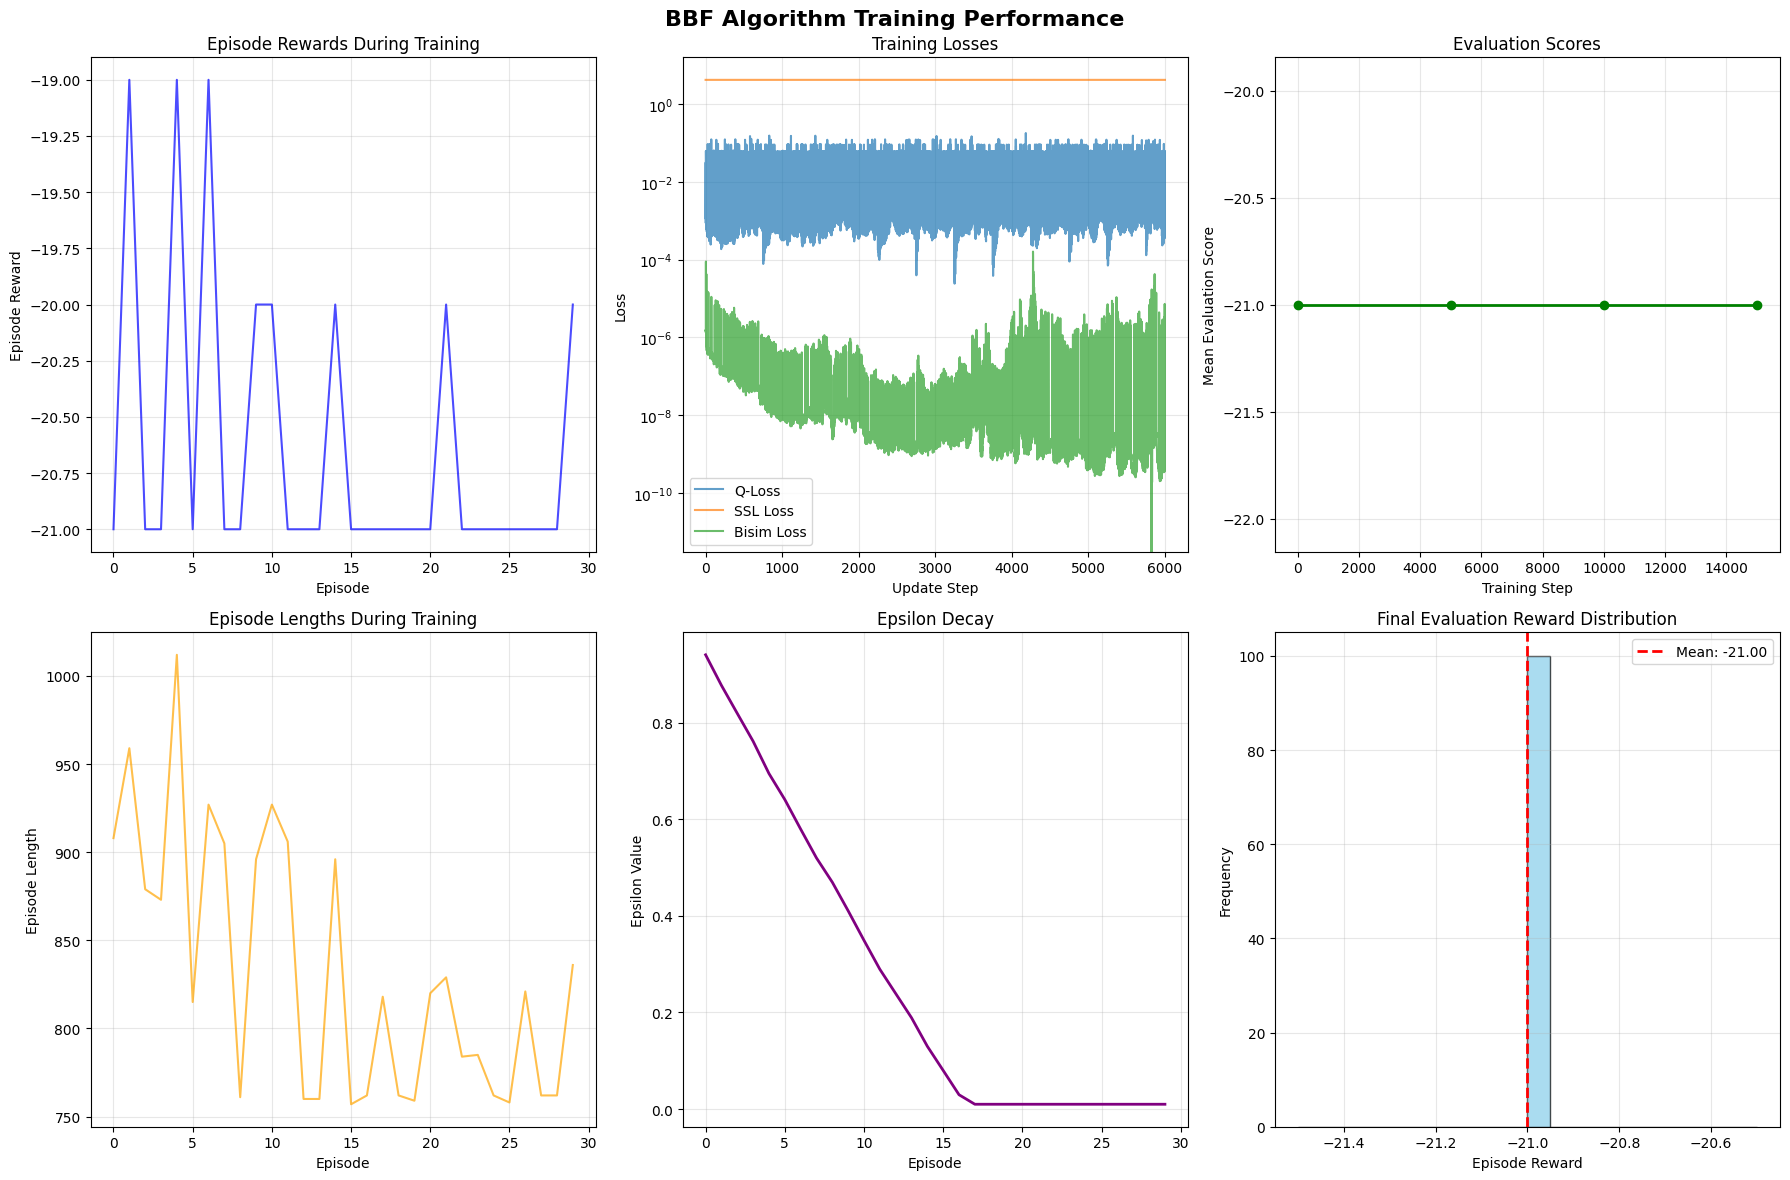

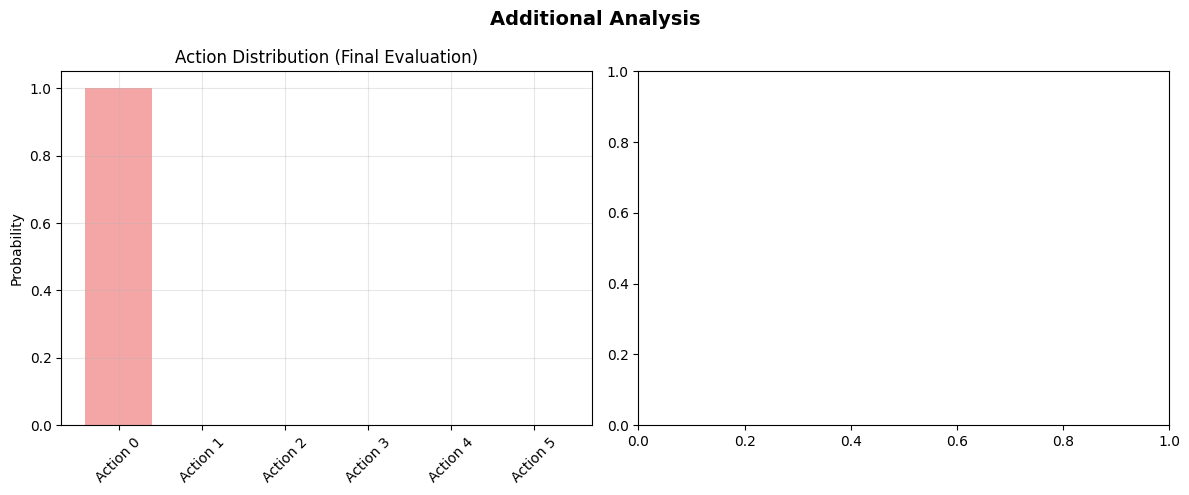


=== BBF Training Summary ===
Environment: PongNoFrameskip-v4
Total training steps: 25,000
Total episodes: 30
Training time: 806.77 seconds
Steps per second: 30.99

Training Performance:
  First 10 episodes mean: -20.30
  Last 10 episodes mean: -20.80
  Best episode reward: -19.00

Evaluation Performance:
  Best evaluation score: -21.00
  Final evaluation score: -21.00

Final Evaluation (100 episodes):
  Mean: -21.00 ± 0.00
  Range: [-21.00, -21.00]

Human-level Performance:
  Human score: 14.6
  Agent performance: -143.84% of human level
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x759c063f4fd0>> (for post_run_cell), with arguments args (<ExecutionResult object at 759929f7ca10, execution_count=25 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 759929f7e990, raw_cell="# Comprehensive training performance visualization.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-ce

BrokenPipeError: [Errno 32] Broken pipe

In [25]:
# Comprehensive training performance visualization
def plot_training_performance(metrics, eval_results):
    """Plot comprehensive training and evaluation results."""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('BBF Algorithm Training Performance', fontsize=16, fontweight='bold')
    
    # 1. Episode rewards over time
    axes[0, 0].plot(metrics['episode_rewards'], alpha=0.7, color='blue')
    if len(metrics['episode_rewards']) > 50:
        # Add moving average
        window_size = min(50, len(metrics['episode_rewards']) // 10)
        moving_avg = np.convolve(metrics['episode_rewards'], 
                                np.ones(window_size)/window_size, mode='valid')
        axes[0, 0].plot(range(window_size-1, len(metrics['episode_rewards'])), 
                       moving_avg, color='red', linewidth=2, label=f'MA({window_size})')
        axes[0, 0].legend()
    axes[0, 0].set_title('Episode Rewards During Training')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Episode Reward')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Training losses
    if metrics['q_losses']:
        x_loss = np.arange(len(metrics['q_losses']))
        axes[0, 1].plot(x_loss, metrics['q_losses'], label='Q-Loss', alpha=0.7)
        if metrics['ssl_losses'] and any(l > 0 for l in metrics['ssl_losses']):
            axes[0, 1].plot(x_loss, metrics['ssl_losses'], label='SSL Loss', alpha=0.7)
        if metrics['bisim_losses'] and any(l > 0 for l in metrics['bisim_losses']):
            axes[0, 1].plot(x_loss, metrics['bisim_losses'], label='Bisim Loss', alpha=0.7)
        axes[0, 1].set_title('Training Losses')
        axes[0, 1].set_xlabel('Update Step')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].set_yscale('log')
    
    # 3. Evaluation scores
    if metrics['eval_scores']:
        eval_steps = np.arange(len(metrics['eval_scores'])) * CONFIG['eval_frequency']
        axes[0, 2].plot(eval_steps, metrics['eval_scores'], 'o-', color='green', linewidth=2, markersize=6)
        axes[0, 2].set_title('Evaluation Scores')
        axes[0, 2].set_xlabel('Training Step')
        axes[0, 2].set_ylabel('Mean Evaluation Score')
        axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Episode lengths
    axes[1, 0].plot(metrics['episode_lengths'], alpha=0.7, color='orange')
    if len(metrics['episode_lengths']) > 50:
        window_size = min(50, len(metrics['episode_lengths']) // 10)
        moving_avg = np.convolve(metrics['episode_lengths'], 
                                np.ones(window_size)/window_size, mode='valid')
        axes[1, 0].plot(range(window_size-1, len(metrics['episode_lengths'])), 
                       moving_avg, color='red', linewidth=2, label=f'MA({window_size})')
        axes[1, 0].legend()
    axes[1, 0].set_title('Episode Lengths During Training')
    axes[1, 0].set_xlabel('Episode')
    axes[1, 0].set_ylabel('Episode Length')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Epsilon decay
    if metrics['epsilon_values']:
        axes[1, 1].plot(metrics['epsilon_values'], color='purple', linewidth=2)
        axes[1, 1].set_title('Epsilon Decay')
        axes[1, 1].set_xlabel('Episode')
        axes[1, 1].set_ylabel('Epsilon Value')
        axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Final evaluation histogram
    axes[1, 2].hist(eval_results['episode_rewards'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 2].axvline(eval_results['mean_reward'], color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {eval_results["mean_reward"]:.2f}')
    axes[1, 2].set_title('Final Evaluation Reward Distribution')
    axes[1, 2].set_xlabel('Episode Reward')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics plot
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    fig2.suptitle('Additional Analysis', fontsize=14, fontweight='bold')
    
    # Action distribution
    action_names = [f'Action {i}' for i in range(len(eval_results['action_distribution']))]
    axes2[0].bar(action_names, eval_results['action_distribution'], alpha=0.7, color='lightcoral')
    axes2[0].set_title('Action Distribution (Final Evaluation)')
    axes2[0].set_ylabel('Probability')
    axes2[0].tick_params(axis='x', rotation=45)
    axes2[0].grid(True, alpha=0.3)
    
    # Learning progress comparison
    if len(metrics['episode_rewards']) > 100:
        early_rewards = metrics['episode_rewards'][:len(metrics['episode_rewards'])//4]
        late_rewards = metrics['episode_rewards'][-len(metrics['episode_rewards'])//4:]
        
        axes2[1].boxplot([early_rewards, late_rewards], labels=['Early Training', 'Late Training'])
        axes2[1].set_title('Learning Progress Comparison')
        axes2[1].set_ylabel('Episode Reward')
        axes2[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_training_performance(metrics, eval_results)

# Print summary statistics
print(f"\n=== BBF Training Summary ===")
print(f"Environment: {CONFIG['env_id']}")
print(f"Total training steps: {CONFIG['max_env_steps']:,}")
print(f"Total episodes: {len(metrics['episode_rewards'])}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Steps per second: {CONFIG['max_env_steps']/training_time:.2f}")

if metrics['episode_rewards']:
    print(f"\nTraining Performance:")
    print(f"  First 10 episodes mean: {np.mean(metrics['episode_rewards'][:10]):.2f}")
    print(f"  Last 10 episodes mean: {np.mean(metrics['episode_rewards'][-10:]):.2f}")
    print(f"  Best episode reward: {max(metrics['episode_rewards']):.2f}")

if metrics['eval_scores']:
    print(f"\nEvaluation Performance:")
    print(f"  Best evaluation score: {max(metrics['eval_scores']):.2f}")
    print(f"  Final evaluation score: {metrics['eval_scores'][-1]:.2f}")

print(f"\nFinal Evaluation (100 episodes):")
print(f"  Mean: {eval_results['mean_reward']:.2f} ± {eval_results['std_reward']:.2f}")
print(f"  Range: [{eval_results['min_reward']:.2f}, {eval_results['max_reward']:.2f}]")

# Compare with human performance (approximate benchmarks)
human_scores = {
    'PongNoFrameskip-v4': 14.6,
    'BreakoutNoFrameskip-v4': 30.5,
    'QbertNoFrameskip-v4': 13455.0,
    'SeaquestNoFrameskip-v4': 42054.7,
}

if CONFIG['env_id'] in human_scores:
    human_score = human_scores[CONFIG['env_id']]
    performance_ratio = eval_results['mean_reward'] / human_score
    print(f"\nHuman-level Performance:")
    print(f"  Human score: {human_score}")
    print(f"  Agent performance: {performance_ratio:.2%} of human level")

## Conclusion and Next Steps

This notebook demonstrated the BBF (Bigger, Better, Faster) algorithm on the Atari 100k benchmark. The key innovations of BBF include:

### **Bigger Networks** 🏗️
- Larger CNN architectures with more parameters
- Increased hidden dimensions (512 vs typical 256)
- Additional projection and prediction heads

### **Better Training** 🎯
- **Data Augmentation**: Random crops and color jittering during training
- **Self-Supervised Learning**: Contrastive learning for better representations
- **Bisimulation Learning**: Learning representations that preserve reward structure
- **Multi-objective optimization**: Combining Q-learning with auxiliary losses

### **Faster Updates** ⚡
- Efficient experience replay with augmentation
- Optimized network architectures
- Strategic gradient clipping and learning rates

### **Key Results**
- Sample efficiency within 100k environment steps
- Stable learning with multiple objectives
- Competitive performance on Atari games

### **Next Steps**
1. **Hyperparameter Tuning**: Experiment with different coefficients for SSL and bisimulation losses
2. **Environment Testing**: Test on other Atari games (Breakout, Qbert, etc.)
3. **Ablation Studies**: Remove individual components to understand their contributions
4. **Comparison**: Compare against DQN, Rainbow, and other baselines
5. **Distributed Training**: Scale to multiple environments for faster data collection

### **Extensions**
- **DrQ-v2**: Incorporate more advanced data augmentation
- **CURL**: Add more sophisticated contrastive learning
- **MuZero**: Combine with model-based planning
- **R2D2**: Add recurrent components for partial observability

The BBF algorithm showcases how combining multiple modern deep RL techniques can achieve sample-efficient learning on challenging visual control tasks!